# Spotify Song Recommendation System

Content-based recommender using Spotify audio features (1921-2020, 170k+ tracks).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import euclidean_distances

pd.set_option('display.max_columns', None)

## 1. Load and explore the data

In [2]:
data = pd.read_csv('../data/data.csv')
print(data.shape)
data.head()

(169909, 19)


,acousticness,artists,danceability,duration_ms,energy,explicit,id,instrumentalness,key,liveness,loudness,mode,name,popularity,release_date,speechiness,tempo,valence,year
0,0.995,['Carl Woitschach'],0.708,158648,0.1950,0,6KbQ3uYMLKb5jDxLF7wYDD,0.563,10,0.1510,-12.428,1,Singende Bataillone 1. Teil,0,1928,0.0506,118.469,0.7790,1928
1,0.994,"['Robert Schumann', 'Vladimir Horowitz']",0.379,282133,0.0135,0,6KuQTIu1KoTTkLXKrwlLPV,0.901,8,0.0763,-28.454,1,"Fantasiestücke, Op. 111: Più tosto lento",0,1928,0.0462,83.972,0.0767,1928
2,0.604,['Seweryn Goszczyński'],0.749,104300,0.2200,0,6L63VW0PibdM1HDSBoqnoM,0.000,5,0.1190,-19.924,0,Chapter 1.18 - Zamek kaniowski,0,1928,0.9290,107.177,0.8800,1928
3,0.995,['Francisco Canaro'],0.781,180760,0.1300,0,6M94FkXd15sOAOQYRnWPN8,0.887,1,0.1110,-14.734,0,Bebamos Juntos - Instrumental (Remasterizado),0,1928-09-25,0.0926,108.003,0.7200,1928
4,0.990,"['Frédéric Chopin', 'Vladimir Horowitz']",0.210,687733,0.2040,0,6N6tiFZ9vLTSOIxkj8qKrd,0.908,11,0.0980,-16.829,1,"Polonaise-Fantaisie in A-Flat Major, Op. 61",1,1928,0.0424,62.149,0.0693,1928


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 169909 entries, 0 to 169908
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   acousticness      169909 non-null  float64
 1   artists           169909 non-null  object 
 2   danceability      169909 non-null  float64
 3   duration_ms       169909 non-null  int64  
 4   energy            169909 non-null  float64
 5   explicit          169909 non-null  int64  
 6   id                169909 non-null  object 
 7   instrumentalness  169909 non-null  float64
 8   key               169909 non-null  int64  
 9   liveness          169909 non-null  float64
 10  loudness          169909 non-null  float64
 11  mode              169909 non-null  int64  
 12  name              169909 non-null  object 
 13  popularity        169909 non-null  int64  
 14  release_date      169909 non-null  object 
 15  speechiness       169909 non-null  float64
 16  tempo             16

In [4]:
data.isnull().sum()

acousticness        0
artists             0
danceability        0
duration_ms         0
energy              0
explicit            0
id                  0
instrumentalness    0
key                 0
liveness            0
loudness            0
mode                0
name                0
popularity          0
release_date        0
speechiness         0
tempo               0
valence             0
year                0
dtype: int64

## 2. Correlation between audio features

Drop identifier/metadata columns that don't describe the sound of the track itself.

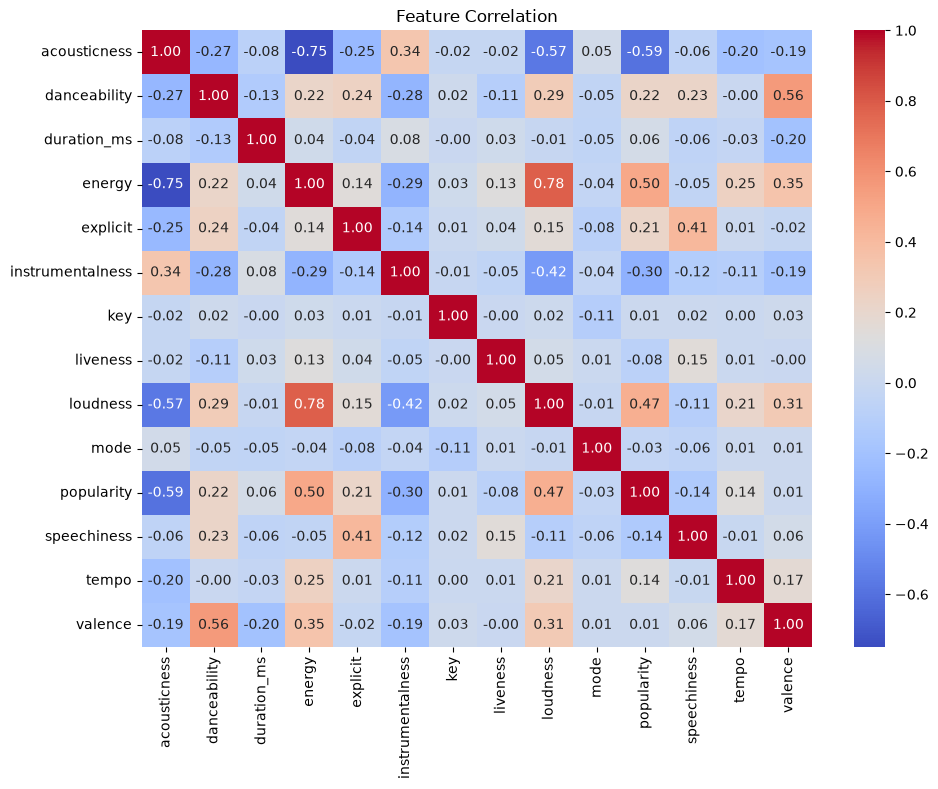

In [5]:
df = data.drop(columns=['id', 'name', 'artists', 'release_date', 'year'])

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation')
plt.tight_layout()
plt.savefig('../outputs/correlation_heatmap.png')
plt.show()

## 3. Scale the audio features

Only the continuous audio-feature columns are scaled (not `id`, `name`, `artists`, `release_date`, `year`,
or the already-categorical `key`/`mode`/`explicit`). `fit_transform` returns the scaled values, which are
assigned back into the dataframe.

In [6]:
feature_cols = ['acousticness', 'danceability', 'duration_ms', 'energy',
                'instrumentalness', 'liveness', 'loudness', 'speechiness',
                'tempo', 'valence']

scaler = MinMaxScaler()
data[feature_cols] = scaler.fit_transform(data[feature_cols])
data[feature_cols].describe()

,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence
count,169909.000000,169909.000000,169909.000000,169909.000000,169909.000000,169909.000000,169909.000000,169909.000000,169909.000000,169909.000000
mean,0.495195,0.544686,0.041920,0.488593,0.161937,0.206690,0.761565,0.097067,0.479116,0.532095
std,0.378140,0.177475,0.022474,0.267390,0.309329,0.176796,0.088744,0.154734,0.125883,0.262408
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.094880,0.422065,0.030737,0.263000,0.000000,0.098400,0.713022,0.036017,0.383119,0.322000
50%,0.493976,0.554656,0.037695,0.481000,0.000204,0.135000,0.775601,0.046440,0.470226,0.544000
75%,0.891566,0.675101,0.047765,0.710000,0.086800,0.263000,0.828158,0.077812,0.555989,0.749000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## 4. (Optional) Cluster songs by sound

Adds a `cluster` label so the recommender can also account for overall "sound category",
not just raw feature distance.

In [7]:
kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
data['cluster'] = kmeans.fit_predict(data[feature_cols])
data['cluster'].value_counts().sort_index()

cluster
0     6503
1    26617
2    27863
3    13269
4    33383
5    19211
6    21725
7    10415
8     4245
9     6678
Name: count, dtype: int64

### Feature distributions

What do these 10 scaled audio features actually look like across 170k tracks?

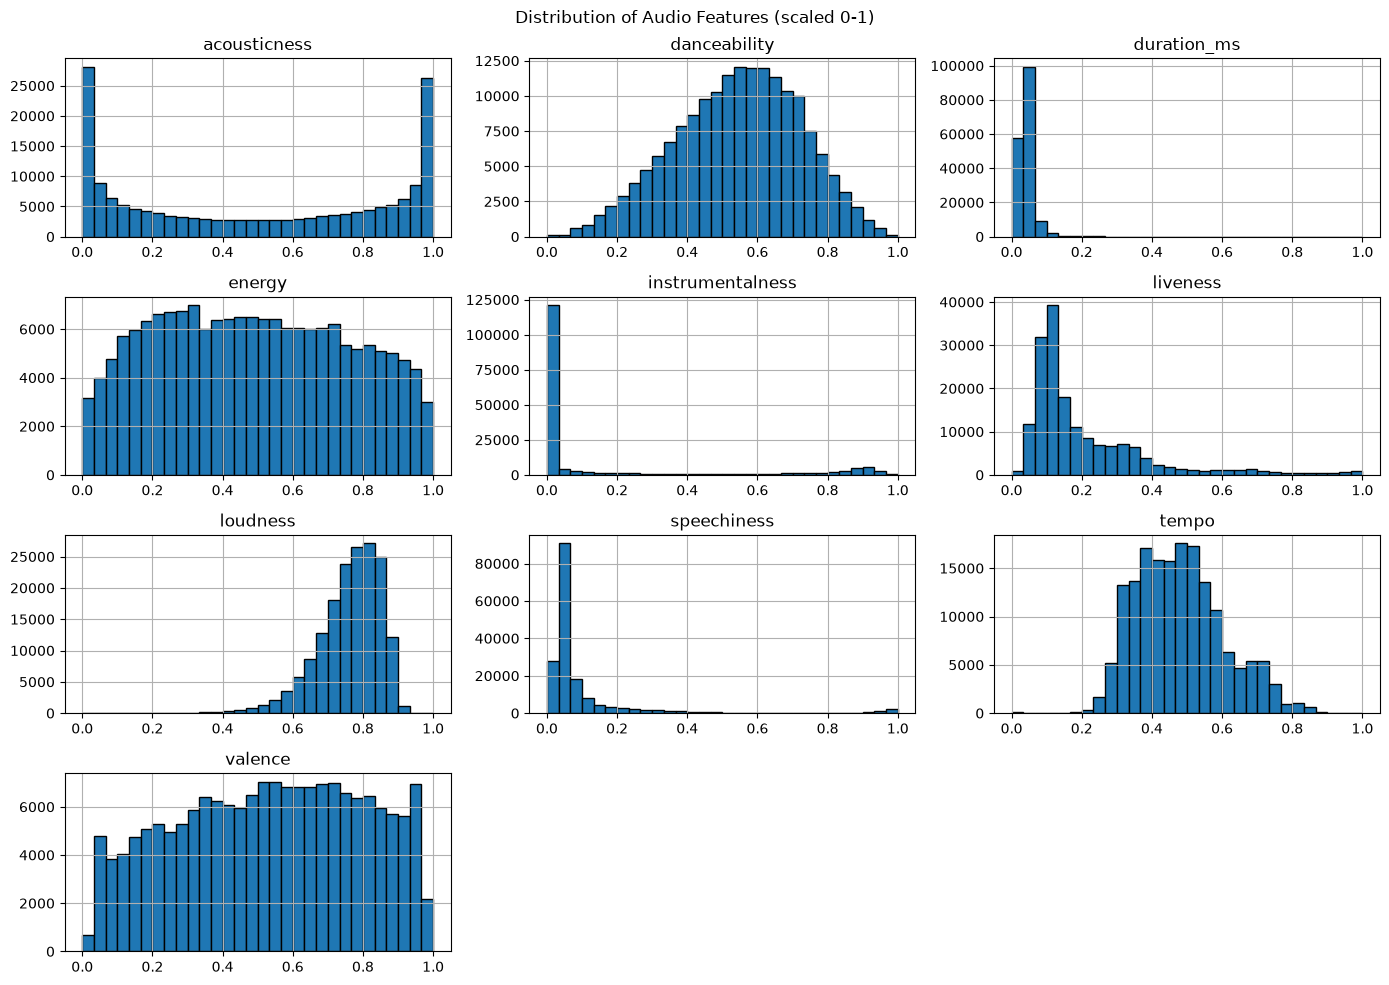

In [8]:
data[feature_cols].hist(figsize=(14, 10), bins=30, edgecolor='black')
plt.suptitle('Distribution of Audio Features (scaled 0-1)')
plt.tight_layout()
plt.savefig('../outputs/feature_distributions.png')
plt.show()

### Visualizing the clusters

The K-Means clusters live in 10-dimensional feature space, so they can't be plotted directly. PCA
reduces that down to 2 components (fit on the full dataset, plotted on a 15k-song sample for
readability) to check that the clusters correspond to something structurally real rather than
arbitrary groupings.

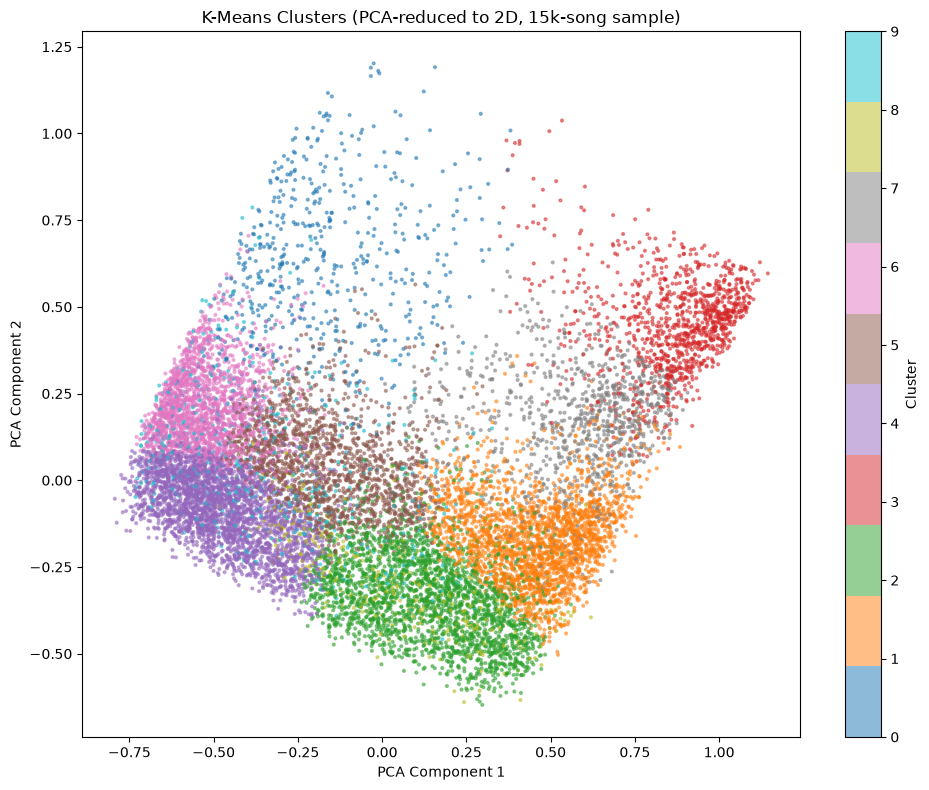

In [9]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
pca.fit(data[feature_cols])

sample = data.sample(15000, random_state=42)
coords = pca.transform(sample[feature_cols])

plt.figure(figsize=(10, 8))
scatter = plt.scatter(coords[:, 0], coords[:, 1], c=sample['cluster'], cmap='tab10', s=4, alpha=0.5)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('K-Means Clusters (PCA-reduced to 2D, 15k-song sample)')
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.savefig('../outputs/cluster_pca.png')
plt.show()

Same sample, but plotted on two features that actually mean something on their own (`energy` vs.
`valence`, i.e. intensity vs. musical positiveness) rather than abstract PCA components — this is
closer to what "same-cluster filtering" is doing under the hood in the recommender.

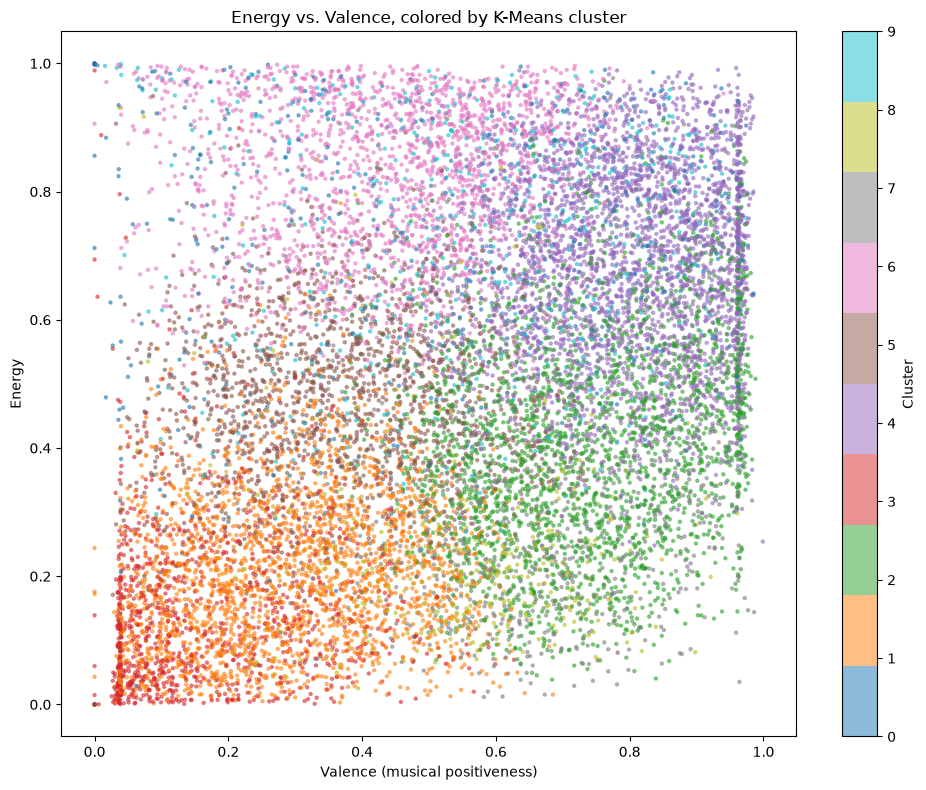

In [10]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(sample['valence'], sample['energy'], c=sample['cluster'], cmap='tab10', s=5, alpha=0.5)
plt.xlabel('Valence (musical positiveness)')
plt.ylabel('Energy')
plt.title('Energy vs. Valence, colored by K-Means cluster')
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.savefig('../outputs/energy_valence_clusters.png')
plt.show()

The clusters overlap far more here than in the PCA plot above — expected, since K-Means grouped
songs using all 10 features, and any 2D slice of a 10-dimensional clustering will lose most of that
structure. Energy and valence alone do show a rough split (high-energy/high-valence clusters top-right,
low-energy/low-valence clusters bottom-left), just not the clean separation PCA's two strongest
components capture.

## 5. Build the recommender

The recommender logic lives in [`src/recommender.py`](../src/recommender.py) rather than inline in the
notebook, so the exact same `SpotifyRecommender` class can be reused by the Streamlit app (`app.py`)
without duplicating code. It improves on the first version in a few ways:

- **Cosine distance** instead of Euclidean by default — better suited to comparing feature *profiles*
  rather than raw magnitude differences.
- **Feature weighting** — `danceability`, `energy`, and `valence` are weighted 1.5x by default, since
  those tend to matter more for how a song "feels" than e.g. `duration_ms` or `key`.
- **Same-cluster filtering** — candidates are first narrowed down to the same K-Means cluster as the
  query song (computed in section 4) before ranking by distance, so we're only ever comparing
  already similar-sounding tracks against each other. Falls back to the full dataset if a cluster is
  too small to satisfy the requested amount.
- **Popularity-aware re-ranking** — among similarly-distant candidates, more popular tracks are
  nudged higher, controlled by a `popularity_boost` parameter. The default is a modest `0.01`, not
  `0.1` — see section 7 for why that matters.

In [11]:
import sys
sys.path.append('..')
from src.recommender import SpotifyRecommender

recommender = SpotifyRecommender(data, feature_cols)

## 6. Try it out

In [12]:
recommender.recommend("WonderWall", amount=10)

,artists,name,distance,popularity
0,['Russell Dickerson'],Blue Tacoma,0.001383,70
1,['The Black Keys'],Lonely Boy,0.002189,72
2,['Bad Religion'],American Jesus,0.001056,60
3,['Red Hot Chili Peppers'],Make You Feel Better,0.000308,52
4,['frederic'],Oddloop,0.000547,54
5,['My Chemical Romance'],You Know What They Do to Guys Like Us in Prison,0.001258,61
6,['Neon Trees'],Everybody Talks,0.002942,77
7,['Three Days Grace'],Home,0.000960,56
8,['Luke Bryan'],What She Wants Tonight,0.002292,69
9,['Nickelback'],Someday,0.002309,69


## 7. Evaluate against known songs

There's no ground truth for "correct" recommendations, so evaluation here is qualitative: run the
recommender against a handful of well-known, stylistically distinct songs and eyeball whether the
results are coherent (similar genre/era/mood) or scattered. First check which of these are actually
present in this particular dataset (exact title match, case-insensitive).

In [13]:
test_songs = ["Billie Jean", "Bohemian Rhapsody", "Hotel California",
              "Smells Like Teen Spirit", "Shape of You", "Wonderwall",
              "Lovers Rock", "Yesterday"]

available_songs = []
for song in test_songs:
    found = not data[data['name'].str.lower() == song.lower()].empty
    print(f"{'FOUND    ' if found else 'not found'} - {song}")
    if found:
        available_songs.append(song)

FOUND     - Billie Jean
FOUND     - Bohemian Rhapsody


FOUND     - Hotel California
FOUND     - Smells Like Teen Spirit
FOUND     - Shape of You


FOUND     - Wonderwall
FOUND     - Lovers Rock
FOUND     - Yesterday


In [14]:
for song in available_songs:
    print(f"\n=== Recommendations for '{song}' ===")
    display(recommender.recommend(song, amount=5))


=== Recommendations for 'Billie Jean' ===


,artists,name,distance,popularity
0,"['Robin Thicke', 'T.I.', 'Pharrell Williams']",Blurred Lines,0.000911,75
1,"['Shawn Mendes', 'Camila Cabello']",Señorita,0.002317,88
2,"['Shawn Mendes', 'Camila Cabello']",Señorita,0.002047,83
3,['Eminem'],The Real Slim Shady,0.001838,80
4,['The Staple Singers'],I'll Take You There,0.000731,66



=== Recommendations for 'Bohemian Rhapsody' ===


,artists,name,distance,popularity
0,['Clint Mansell'],Together We Will Live Forever,0.001040,55
1,['C418'],Sweden,0.002112,65
2,['Aaron Lansing'],Naive Spin,0.002707,64
3,['Oneke'],More than Close,0.002842,64
4,['Ronald Emery'],Say You Wont Let Go,0.003185,65



=== Recommendations for 'Hotel California' ===


...

,artists,name,distance,popularity
0,['Russell Dickerson'],Blue Tacoma,0.001383,70
1,['The Black Keys'],Lonely Boy,0.002189,72
2,['Bad Religion'],American Jesus,0.001056,60
3,['Red Hot Chili Peppers'],Make You Feel Better,0.000308,52
4,['frederic'],Oddloop,0.000547,54



=== Recommendations for 'Lovers Rock' ===


,artists,name,distance,popularity
0,"['Bad Bunny', 'Diplo', 'Nitti Gritti']",200 Mph,0.000351,70
1,['Bruno Mars'],That's What I Like,0.002177,81
2,['Mariah Carey'],We Belong Together,0.001520,69
3,['R. Kelly'],Ignition - Remix,0.001909,70
4,['Fleetwood Mac'],Dreams - 2004 Remaster,0.003201,80



=== Recommendations for 'Yesterday' ===


,artists,name,distance,popularity
0,['Kyle Landry'],Howl's Moving Castle Theme,0.001473,56
1,['Maxence Cyrin'],Where Is My Mind,0.002395,60
2,['Clem Leek'],You’re So Very Far Away,0.001681,52
3,['The Antlers'],Kettering,0.002621,53
4,['Freddie Hubbard'],Dedicated To You,0.002134,44


### Why `popularity_boost` defaults to 0.01, not 0.1

Within a single K-Means cluster, cosine distances between songs are tiny — typically 0.0005 to 0.02.
`popularity_boost` is subtracted directly from that distance
(`score = distance - popularity_boost * popularity/100`), so once the boost gets close to that same
order of magnitude, it stops being a tie-breaker and becomes the dominant signal — the recommender
degrades into "just return whatever's popular in this cluster," regardless of the query song.

In [15]:
for boost in [0, 0.01, 0.1]:
    print(f"\n--- popularity_boost={boost} ---")
    display(recommender.recommend("Billie Jean", amount=5, popularity_boost=boost)[['name', 'distance', 'popularity']])


--- popularity_boost=0 ---


,name,distance,popularity
0,Love Come Down,0.000212,51
1,I'm In Love - Extended Version,0.000359,26
2,Feeling So Good Today,0.000491,38
3,"I'm In Love - 7"" Version",0.000521,27
4,Warm Leatherette,0.000589,35



--- popularity_boost=0.01 ---


,name,distance,popularity
0,Blurred Lines,0.000911,75
1,Señorita,0.002317,88
2,Señorita,0.002047,83
3,The Real Slim Shady,0.001838,80
4,I'll Take You There,0.000731,66



--- popularity_boost=0.1 ---


,name,distance,popularity
0,Sunday Best,0.006235,93
1,Supalonely,0.009022,95
2,Señorita,0.002317,88
3,Ride It,0.004929,90
4,Say So,0.009856,93


## 8. Findings

- **Same-cluster filtering + weighted cosine distance generally improved coherence.** "Smells Like
  Teen Spirit" returned Ram Jam, Avenged Sevenfold, U2, and Mötley Crüe — a solid rock cluster.
  "Yesterday" returned entirely mellow instrumental/piano tracks. "Shape of You" returned Latin/tropical
  pop tracks, which lines up with its reggaeton-influenced production even though none of that is
  encoded as a genre label anywhere in the data — the audio features alone captured it.
- **`popularity_boost` is extremely sensitive**, and the "Billie Jean" sweep above shows why: at `0`,
  the top matches are obscure deep cuts with popularity 26-51; at `0.1`, all five matches are 2019-2020
  hits with popularity 88-95 regardless of how close they actually are in distance — popularity has
  taken over the ranking entirely. `0.01` lands in between (popularity 66-88, spanning 1972-2019),
  acting as a genuine tie-breaker instead of the dominant signal.
- **Aggregate audio features struggle with structurally complex songs.** "Bohemian Rhapsody" shifts
  between a ballad, an operatic section, and hard rock — but the dataset represents it as a single row
  of averaged features, so its nearest neighbors (film-score and ambient tracks) don't feel meaningfully
  related. This is a real limitation of any single-vector, whole-track feature representation, not a bug
  in the distance calculation.
- **The dataset itself has duplicate entries** — e.g. "Señorita" and "Black Betty" both appear twice in
  results above, from separate rows with the same name/artist but slightly different audio feature
  values (likely different releases or re-uploads). A future improvement would be to deduplicate on
  `(name, artists)` before building the recommender.

## Limitations

- **No personalization** — recommendations depend only on the query song's audio features, not on any
  individual user's listening history.
- **Cold-start problem** — a song has to already exist in this dataset (170k tracks, 1921-2020) to be
  queried; newer releases aren't covered.
- **No genre or lyrical awareness** — the model only sees numeric audio features (tempo, loudness,
  danceability, etc.), so two songs can be "close" by the numbers while sounding completely different
  in style, language, or lyrical content.
- **Whole-track averaging** — as shown above with "Bohemian Rhapsody," songs with significant internal
  structure changes aren't well represented by a single averaged feature vector.